# 01 · Exploratory Data Analysis — real housing data

This notebook explores `datasets/ames.csv`, a **real** dataset of 1,460 property
sales in Ames, Iowa (mapped to the project schema). Unlike the dashboard's
synthetic listings, these are actual transactions, so this is where we check the
data before modelling.

We look at: structure, distributions, price skew, geography, size correlations
and outliers.

In [1]:
import os, sys
for _candidate in (os.getcwd(), os.path.dirname(os.getcwd())):
    if os.path.exists(os.path.join(_candidate, "config.py")) and _candidate not in sys.path:
        sys.path.insert(0, _candidate)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import config
import real_data

pd.set_option("display.width", 140)
plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["axes.grid"] = True

df = real_data.load_real_data()
print("shape:", df.shape)
df.head()

shape: (1460, 10)


,bedrooms,bathrooms,sqft,lot_size,year_built,has_pool,garage_spaces,market,neighborhood,price
0,3,2.5,1710,8450,2003,False,2,"Ames, IA",CollgCr,208500.0
1,3,2.0,1262,9600,1976,False,2,"Ames, IA",Veenker,181500.0
2,3,2.5,1786,11250,2001,False,2,"Ames, IA",CollgCr,223500.0
3,3,1.0,1717,9550,1915,False,3,"Ames, IA",Crawfor,140000.0
4,4,2.5,2198,14260,2000,False,3,"Ames, IA",NoRidge,250000.0


## Structure & summary

In [2]:
df.dtypes.to_frame("dtype")

,dtype
bedrooms,int64
bathrooms,float64
sqft,int64
lot_size,int64
year_built,int64
has_pool,bool
garage_spaces,int64
market,str
neighborhood,str
price,float64


In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
bedrooms,1460.0,2.866438,0.815778,0.0,2.0,3.0,3.00,8.0
bathrooms,1460.0,1.756507,0.636015,0.0,1.0,2.0,2.50,3.5
sqft,1460.0,1515.463699,525.480383,334.0,1129.5,1464.0,1776.75,5642.0
lot_size,1460.0,10516.828082,9981.264932,1300.0,7553.5,9478.5,11601.50,215245.0
year_built,1460.0,1971.267808,30.202904,1872.0,1954.0,1973.0,2000.00,2010.0
garage_spaces,1460.0,1.767123,0.747315,0.0,1.0,2.0,2.00,4.0
price,1460.0,180921.195890,79442.502883,34900.0,129975.0,163000.0,214000.00,755000.0


## Missing values

In [4]:
df.isna().sum().sort_values(ascending=False).to_frame("missing")

,missing
bedrooms,0
bathrooms,0
sqft,0
lot_size,0
year_built,0
has_pool,0
garage_spaces,0
market,0
neighborhood,0
price,0


## Target distribution — price is right-skewed

Property prices are log-normal-ish, which is why the model trains on `log1p(price)`.

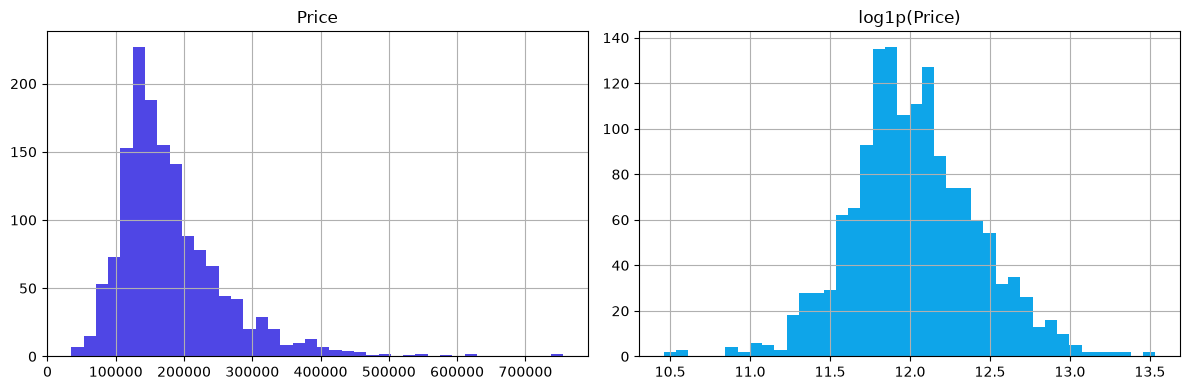

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df["price"], bins=40, color=config.COLORS["primary"])
axes[0].set_title("Price")
axes[1].hist(np.log1p(df["price"]), bins=40, color=config.COLORS["accent"])
axes[1].set_title("log1p(Price)")
plt.tight_layout()
plt.show()

## Price by neighbourhood

Location is the dominant driver, as expected in real estate.

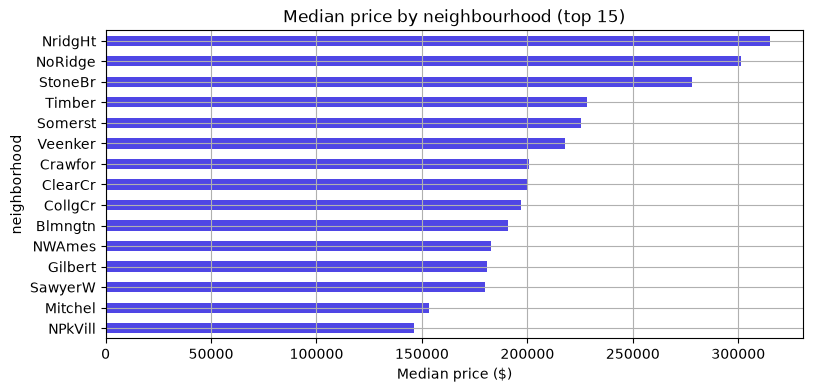

In [6]:
top = df.groupby("neighborhood")["price"].median().sort_values().tail(15)
top.plot(kind="barh", color=config.COLORS["primary"])
plt.title("Median price by neighbourhood (top 15)")
plt.xlabel("Median price ($)")
plt.show()

## Size vs. price

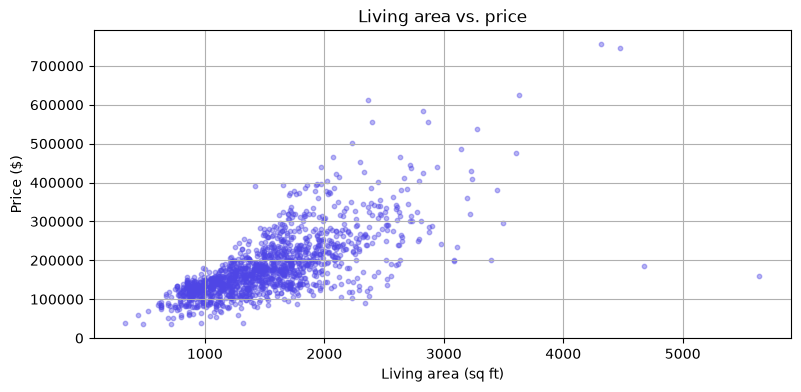

corr(sqft, price) = 0.709


In [7]:
plt.scatter(df["sqft"], df["price"], s=10, alpha=0.4, color=config.COLORS["primary"])
plt.xlabel("Living area (sq ft)")
plt.ylabel("Price ($)")
plt.title("Living area vs. price")
plt.show()

print("corr(sqft, price) =", round(df["sqft"].corr(df["price"]), 3))

## Correlation between numeric features

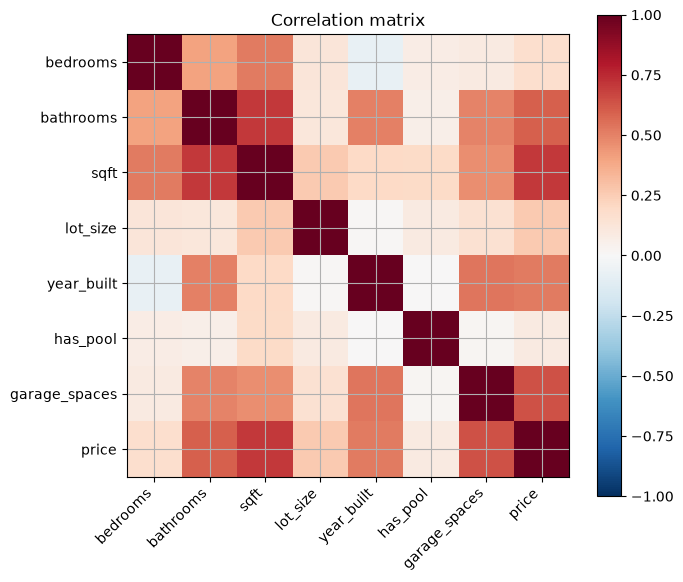

In [8]:
numeric = config.NUMERIC_FEATURES + ["price"]
corr = df[numeric].corr()
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(numeric)), numeric, rotation=45, ha="right")
ax.set_yticks(range(len(numeric)), numeric)
fig.colorbar(im, ax=ax)
plt.title("Correlation matrix")
plt.tight_layout()
plt.show()

## Outliers — highest-priced sales

In [9]:
df.nlargest(8, "price")[["neighborhood", "sqft", "bedrooms", "bathrooms", "year_built", "price"]]

,neighborhood,sqft,bedrooms,bathrooms,year_built,price
691,NoRidge,4316,4,3.5,1994,755000.0
1182,NoRidge,4476,4,3.5,1996,745000.0
1169,NoRidge,3627,4,3.5,1995,625000.0
898,NridgHt,2364,2,2.5,2009,611657.0
803,NridgHt,2822,4,3.5,2008,582933.0
1046,StoneBr,2868,4,3.5,2005,556581.0
440,NridgHt,2402,2,2.0,2008,555000.0
769,StoneBr,3279,4,3.5,2003,538000.0


## Takeaways

- Prices are **right-skewed** → model the `log1p` target.
- **Location** (neighbourhood) and **size** are the strongest signals.
- A few very large/pricey homes act as outliers; the pipeline's scaling and the
  tree model keep this manageable.

Next: `02_modeling.ipynb` fits and evaluates the pipeline.